In [45]:
import json
import os
import ctypes

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from pycocotools.coco import COCO


os.environ["SM_FRAMEWORK"]="tf.keras"
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.utils import Sequence, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten,Conv2D, MaxPooling2D,BatchNormalization
from keras_preprocessing.image import img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint
import segmentation_models as sm
from tensorflow.keras.models import Sequential

In [2]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)


-2147483648

In [3]:
test_img="./arcade/stenosis/test/images/"
train_img="./arcade/stenosis/train/images/"
val_img="./arcade/stenosis/val/images/"

In [4]:
js_train="./arcade/stenosis/train/annotations/train.json"
js_val="./arcade/stenosis/val/annotations/val.json"
js_test="./arcade/stenosis/test/annotations/test.json"

with open (js_train,"r") as f:
    js_tra=json.load(f)

with open (js_val,"r") as b:
    js_v=json.load(b)

with open (js_test,"r") as c:
    js_te=json.load(c)

In [5]:
def load_imggg(join_path,img_dir):
    coco=COCO(join_path,)
    img_di=coco.getImgIds()
    img=[]
    for i in img_di:
        img_l=coco.loadImgs(i)[0]
        img_path=os.path.join(img_dir,img_l["file_name"])
        imgg=load_img(img_path,target_size=(512,512),color_mode="grayscale")
        imgg=img_to_array(imgg)
        img.append(imgg)
    return np.array(img)

x_train=load_imggg(js_train,train_img)
x_test=load_imggg(js_test,test_img)
x_val=load_imggg(js_val,val_img)

print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("x_val shape:",x_val.shape)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
x_train shape: (1000, 512, 512, 1)
x_test shape: (300, 512, 512, 1)
x_val shape: (200, 512, 512, 1)


In [6]:
print("train:",x_train.shape)
print("test:",x_test.shape)
print("val:",x_val.shape)

train: (1000, 512, 512, 1)
test: (300, 512, 512, 1)
val: (200, 512, 512, 1)


In [7]:
def make_masks(json_path):
    coco=COCO(json_path)
    img_ids=coco.getImgIds()
    masks=[]

    for img_id in img_ids:

        img_info=coco.loadImgs(img_id)[0]
        anns=coco.loadAnns(coco.getAnnIds(imgIds=img_id))
        mask=np.zeros(
            (img_info["height"],img_info["width"]),
            dtype=np.uint8)
        for ann in anns:
            mask=np.maximum(mask,coco.annToMask(ann))

        mask=Image.fromarray(mask)
        mask=mask.resize(
            (512,512),
            Image.NEAREST)
        masks.append(np.array(mask))
    masks=np.array(masks)
    masks=np.expand_dims(masks,-1)

    return masks

In [8]:
y_train=make_masks(js_train)
y_val=make_masks(js_val)
y_test=make_masks(js_test)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [9]:
print("val mask:",y_val.shape)
print("test mask:",y_test.shape)
print("train mask:",y_train.shape)

val mask: (200, 512, 512, 1)
test mask: (300, 512, 512, 1)
train mask: (1000, 512, 512, 1)


In [10]:
print(x_train.shape)
print(y_train.shape)

(1000, 512, 512, 1)
(1000, 512, 512, 1)


In [11]:
print(js_tra["images"][0])
print("image:",x_train[0].shape)
print("mask:",y_train[0].shape)

{'id': 676, 'width': 512, 'height': 512, 'file_name': '676.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
image: (512, 512, 1)
mask: (512, 512, 1)


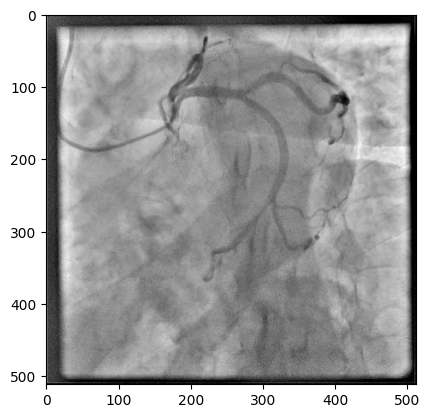

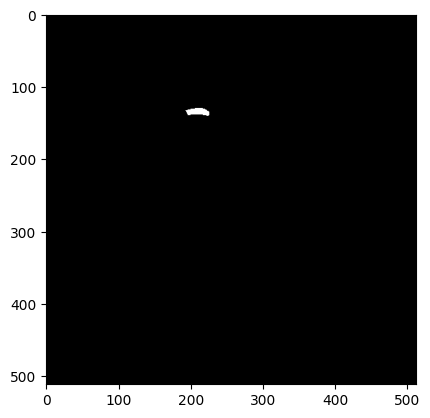

In [12]:
plt.imshow(x_train[0].squeeze(),cmap="gray")
plt.show()

plt.imshow(y_train[0].squeeze(),cmap="gray")
plt.show()

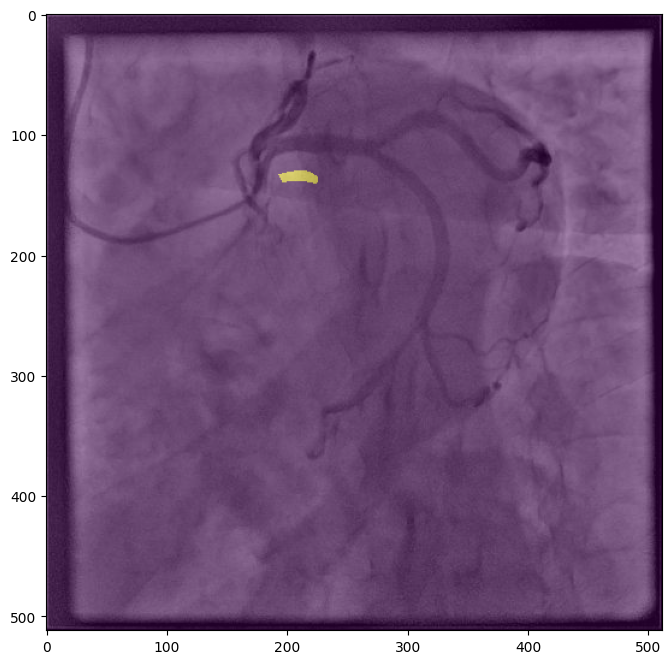

In [13]:
plt.figure(figsize=(8,8))

plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.imshow(y_train[0].squeeze(),alpha=0.5)

plt.show()

In [14]:
x_train=x_train/255.0
x_val=x_val/255.0
x_test=x_test/255.0

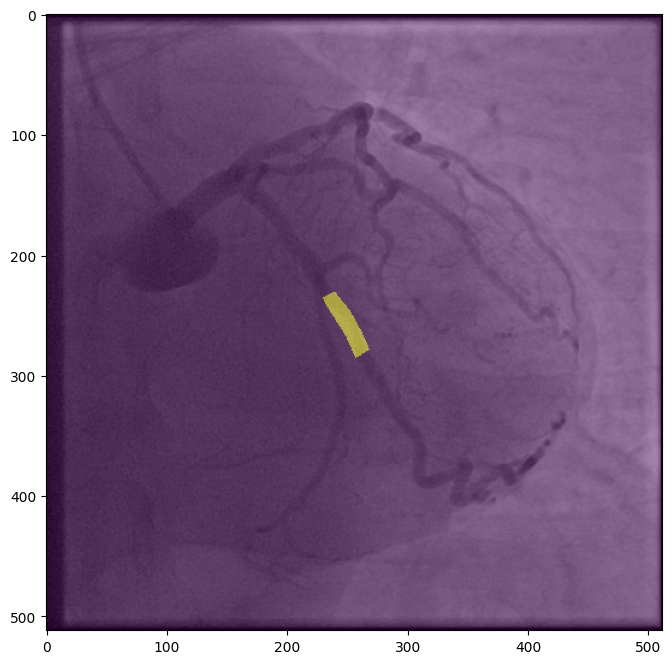

In [15]:
i=0

plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(),cmap="gray")
plt.imshow(y_test[i].squeeze(),alpha=0.5)

plt.show()

In [16]:
model=sm.Unet('resnet34',input_shape=(512,512,1),activation="sigmoid",encoder_weights=None,classes=1)

In [17]:
# fte=sm.losses.BinaryFocalLoss()
# doct=sm.losses.DiceLoss()
# com=fte+doct

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="binary_crossentropy",metrics=["accuracy"])


In [19]:
gpu=tf.config.list_physical_devices("GPU")
print(gpu)

[]


In [20]:
# data_gen=dict(rotation_range=10,zoom_range=0.05,horizontal_flip=True,vertical_flip=True,fill_mode="constant",cval=0)
# img_gen=ImageDataGenerator(**data_gen)
# msk_gen=ImageDataGenerator(**data_gen)
#
# seed=42
# img_gen_a=img_gen.flow(x_train,batch_size=2,seed=seed)
# img_gen_b=img_gen.flow(y_train,batch_size=2,seed=seed)

In [21]:
# def gen():
#     for img_batach,msk_batch in zip(img_gen_a,img_gen_b):
#         yield img_batach,msk_batch
# train_gen=gen()

In [22]:
# steps=len(x_train)//2

In [23]:
ckp=ModelCheckpoint("heart_ckp.keras",monitor="val_loss",save_best_only=True)

In [24]:
history=model.fit(x_train,y_train,batch_size=4,validation_data=(x_val,y_val),epochs=50,callbacks=[ckp])

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1713s 7s/step - accuracy: 0.9921 - loss: 0.0509 - val_accuracy: 0.9920 - val_loss: 0.0460
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.9927 - loss: 0.0337 - val_accuracy: 0.9920 - val_loss: 0.0411
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 596s 2s/step - accuracy: 0.9927 - loss: 0.0317 - val_accuracy: 0.9920 - val_loss: 0.0337
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - accuracy: 0.9927 - loss: 0.0309 - val_accuracy: 0.9920 - val_loss: 0.0296
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2141s 9s/step - accuracy: 0.9927 - loss: 0.0302 - val_accuracy: 0.9920 - val_loss: 0.0277
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2147s 9s/step - accuracy: 0.9927 - loss: 0.0300 - val_accuracy: 0.9920 - val_loss: 0.0265
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2057s 8s/step - accuracy: 0.9927 - loss: 0.0294 - val_accuracy: 0.9920 - val_loss: 0.0282
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2094s 8s/step - accuracy: 0.9927 - loss: 0.0288 - val

In [25]:
model.save("heart_try_for_better.keras")

In [26]:
print(f" count train:{len(os.listdir(train_img))}")
print(f" count val:{len(os.listdir(val_img))}")
print(f" count test:{len(os.listdir(test_img))}")

 count train:1000
 count val:200
 count test:300


In [27]:
print(len(history.history["loss"]))
print(history.history["loss"])

50
[0.05092212185263634, 0.033672865480184555, 0.031685736030340195, 0.03088170848786831, 0.030205314978957176, 0.03001881204545498, 0.02938426099717617, 0.02880028635263443, 0.028702741488814354, 0.02826654724776745, 0.027925118803977966, 0.0275304913520813, 0.02730429358780384, 0.026660073548555374, 0.02649523690342903, 0.026265505701303482, 0.025884311646223068, 0.025658128783106804, 0.025108182802796364, 0.024615904316306114, 0.02428419142961502, 0.024105895310640335, 0.023620285093784332, 0.02341555431485176, 0.022912468761205673, 0.022476179525256157, 0.021742451936006546, 0.021447956562042236, 0.020575501024723053, 0.01969989202916622, 0.019140152260661125, 0.018001552671194077, 0.01740626059472561, 0.016080675646662712, 0.014976122416555882, 0.013973128981888294, 0.013046913780272007, 0.012536775320768356, 0.011440315283834934, 0.010734549723565578, 0.009952632710337639, 0.009357894770801067, 0.008839811198413372, 0.008575948886573315, 0.007907254621386528, 0.007178704254329204

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


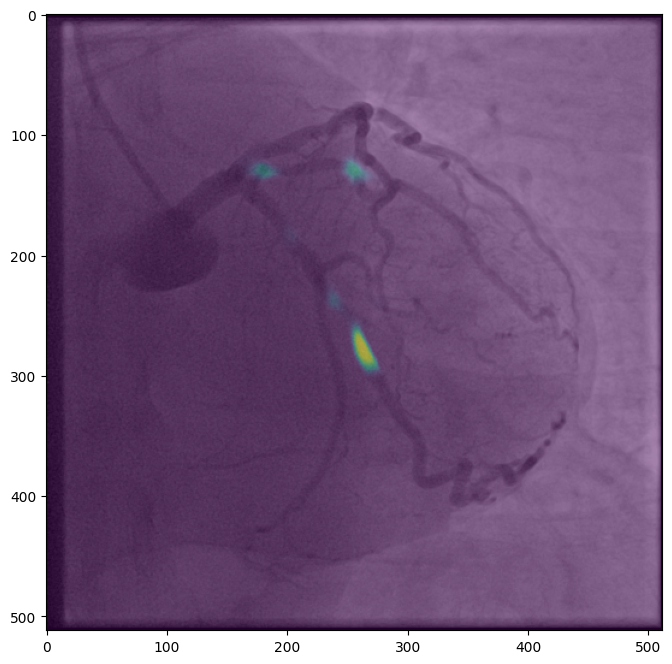

In [28]:
i=0
pred=model.predict(x_test[i:i+1])
plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(),cmap="gray")
plt.imshow(pred[0].squeeze(),alpha=0.5)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step


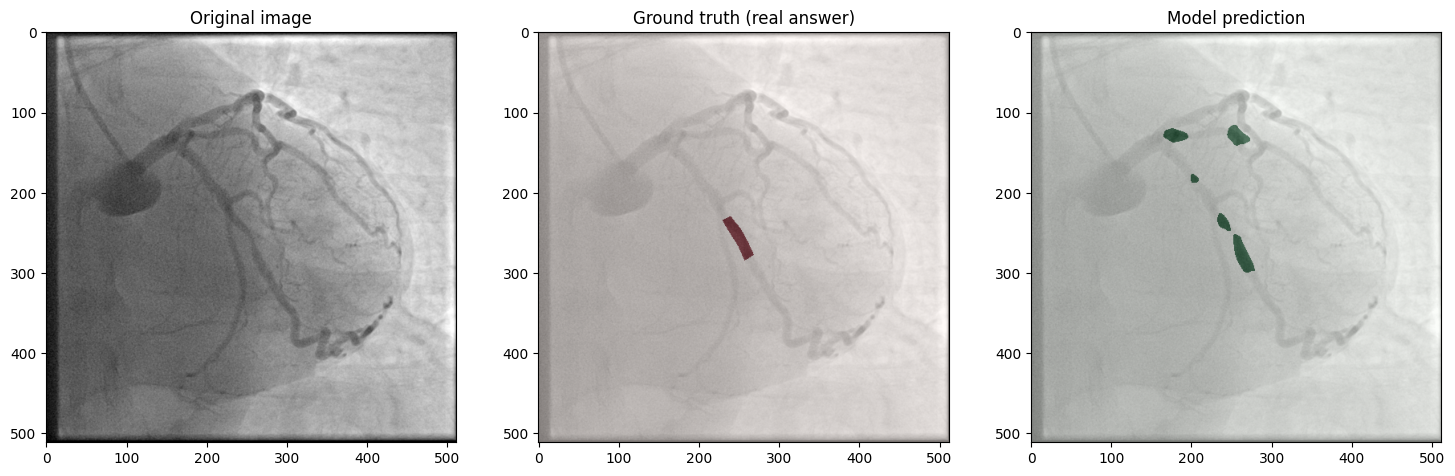

IoU 0.24178962
Dice 0.38942122


In [29]:
i = 0

pred=model.predict(x_test[i:i+1])
pred_mask=(pred[0]>0.05).astype("uint8")

fig,axes=plt.subplots(1,3,figsize=(18, 6))

axes[0].imshow(x_test[i].squeeze(),cmap="gray")
axes[0].set_title("Original image")
axes[1].imshow(x_test[i].squeeze(),cmap="gray")
axes[1].imshow(y_test[i].squeeze(),alpha=0.5,cmap="Reds")
axes[1].set_title("Ground truth (real answer)")
axes[2].imshow(x_test[i].squeeze(),cmap="gray")
axes[2].imshow(pred_mask.squeeze(),alpha=0.5,cmap="Greens")
axes[2].set_title("Model prediction")

plt.show()

from segmentation_models.metrics import IOUScore, FScore
y_single=y_test[i:i+1].astype("float32")
pred_single=pred.astype("float32")
iou=IOUScore(threshold=0.05)
dice=FScore(beta=1, threshold=0.05)

print("IoU",iou(y_single,pred_single).numpy())
print("Dice",dice(y_single,pred_single).numpy())

In [30]:
new_im="F://54.png"
img_loder_test=load_img(new_im,target_size=(512,512),color_mode="grayscale")

img=img_to_array(img_loder_test)
img=img/255.0
img=np.expand_dims(img,axis=0)
pred=model.predict(img)
pred_mask=pred[0]
pred_msk=(pred_mask>0.5).astype("uint8")
print(pred_msk.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
(512, 512, 1)


In [31]:
new_im3="F://290.png"
img_loder_test3=load_img(new_im3,target_size=(512, 512),color_mode="grayscale")

img3=img_to_array(img_loder_test3)
img3=img3/255.0
img3=np.expand_dims(img3,axis=0)
pred3=model.predict(img3)
pred_mask3=pred3[0]
pred_msk3=(pred_mask3>0.5).astype("uint8")
print(pred_msk3.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
(512, 512, 1)


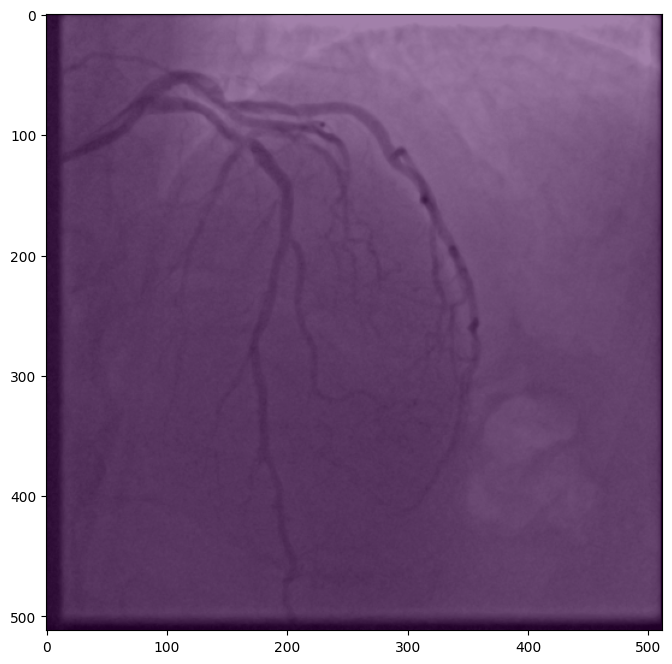

In [32]:
plt.figure(figsize=(8,8))
plt.imshow(img3[0].squeeze(), cmap="gray")
plt.imshow(pred_msk3.squeeze(),alpha=0.5)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


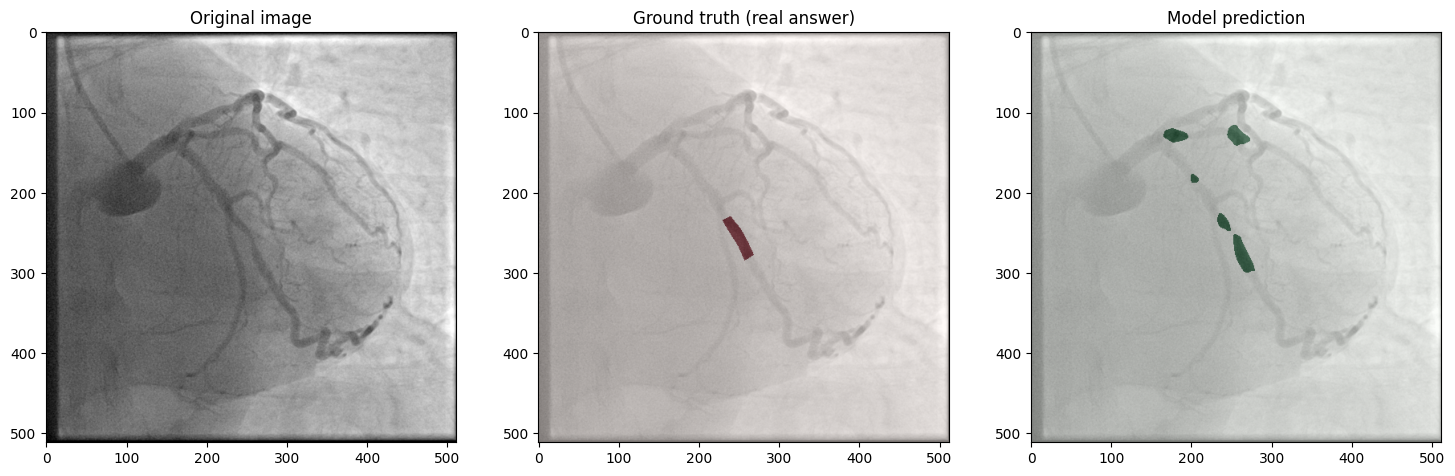

IoU 0.24178962
Dice 0.38942122


In [33]:
i2=0

pred3=model.predict(x_test[i2:i2+1])
pred_mask3=(pred3[0]>0.05).astype("uint8")

fig,axes=plt.subplots(1,3,figsize=(18, 6))

axes[0].imshow(x_test[i2].squeeze(),cmap="gray")
axes[0].set_title("Original image")
axes[1].imshow(x_test[i2].squeeze(),cmap="gray")
axes[1].imshow(y_test[i].squeeze(),alpha=0.5,cmap="Reds")
axes[1].set_title("Ground truth (real answer)")
axes[2].imshow(x_test[i2].squeeze(),cmap="gray")
axes[2].imshow(pred_mask3.squeeze(),alpha=0.5,cmap="Greens")
axes[2].set_title("Model prediction")

plt.show()

from segmentation_models.metrics import IOUScore, FScore
y_single3=y_test[i2:i2+1].astype("float32")
pred_single3=pred3.astype("float32")
iou3=IOUScore(threshold=0.05)
dice3=FScore(beta=1, threshold=0.05)

print("IoU",iou(y_single3,pred_single3).numpy())
print("Dice",dice(y_single3,pred_single3).numpy())

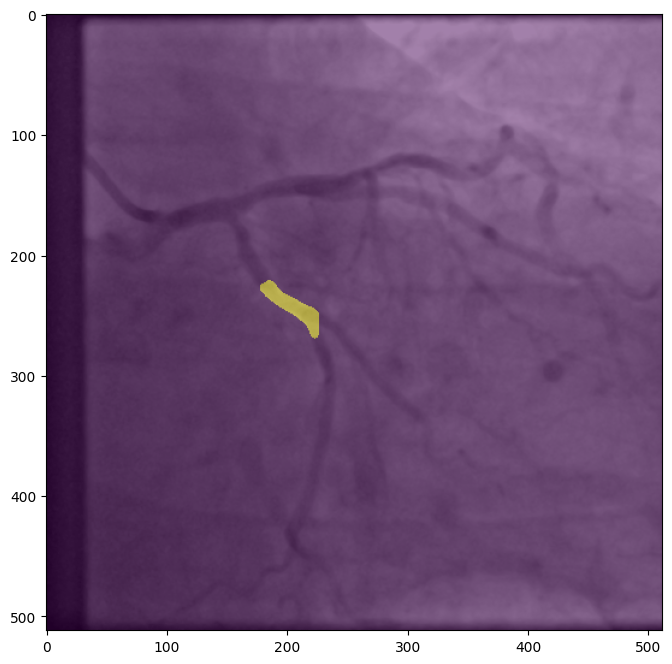

In [34]:
plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(), cmap="gray")
plt.imshow(pred_msk.squeeze(),alpha=0.5)
plt.show()

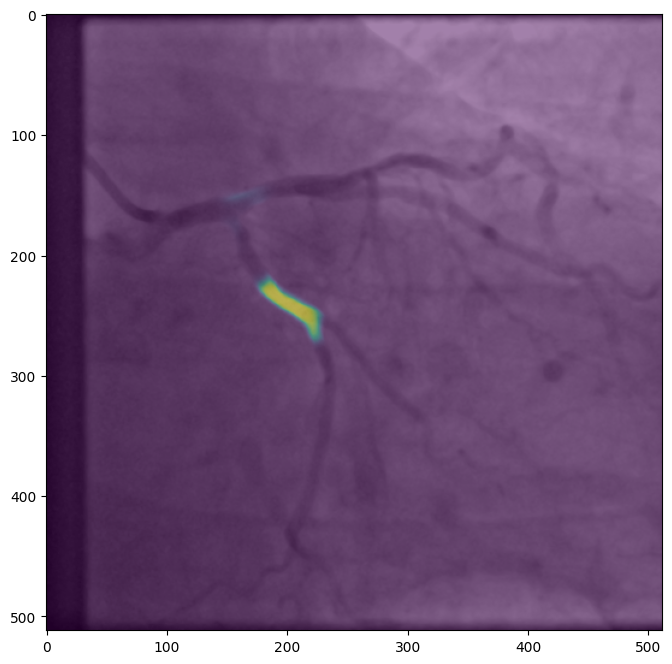

In [35]:
pred_msk=(pred_mask>0.1).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(),cmap="gray")
plt.imshow(pred_mask.squeeze(),alpha=0.5)
plt.show()

In [36]:
print(pred.min(), pred.max(), pred.mean())

4.7063237e-10 0.996632 0.0033053681


In [37]:
new_im2="F://165.png"
img_loder_test2=load_img(new_im2,target_size=(512,512),color_mode="grayscale")

img2=img_to_array(img_loder_test2)
img2=img2/255.0
img2=np.expand_dims(img2,axis=0)
pred2=model.predict(img2)
pred_mask2=pred2[0]
pred_msk2=(pred_mask2>0.5).astype("uint8")
print(pred_msk2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
(512, 512, 1)


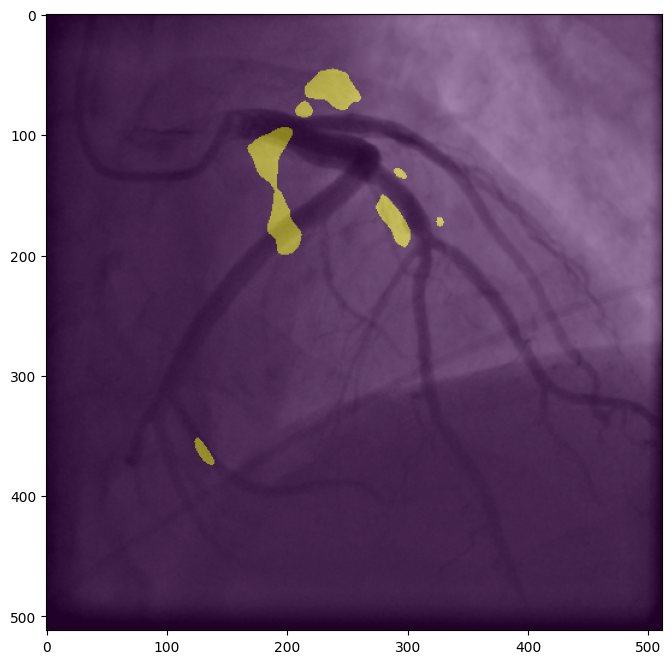

In [38]:
test_again=(pred_mask2>0.1).astype("uint8")

plt.figure(figsize=(8,8))

plt.imshow(img2[0].squeeze(),cmap="gray")
plt.imshow(test_again.squeeze(),alpha=0.5)

plt.show()

In [39]:
print(pred.max())
print(pred.min())
print(np.sum(pred_msk))

0.996632
4.7063237e-10
1341


In [41]:
print("min:", pred_test.min())
print("max:", pred_test.max())
print("mean:", pred_test.mean())

NameError: name 'pred_test' is not defined

In [40]:
from segmentation_models.metrics import IOUScore,FScore
pred_test=model.predict(x_test)

y_test=y_test.astype("float32")

pred_mask2=pred_mask2.astype("float32")

iou=IOUScore(threshold=0.5)
dice=FScore(beta=1,threshold=0.5)

print("IOU:",iou(y_test,pred_test).numpy())
print("Dice:",dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step
IOU: 0.18660358
Dice: 0.3145171


In [41]:
for t in [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou = IOUScore(threshold=t)
    dice = FScore(beta=1, threshold=t)
    print(t, iou(y_test, pred_test).numpy(), dice(y_test, pred_test).numpy())

0.01 0.24558003 0.39432237
0.02 0.25732723 0.40932417
0.03 0.26230463 0.41559643
0.05 0.2641738 0.41793907
0.1 0.25798315 0.4101536
0.2 0.24129744 0.38878262
0.3 0.22374743 0.36567584
0.4 0.20532085 0.3406908
0.5 0.18660358 0.3145171


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.tight_layout()
plt.show()

In [ ]:
def load_images_coco(json_path, img_dir):
    coco=COCO(json_path)
    img_ids=coco.getImgIds()
    images=[]
    for img_id in img_ids:
        img_p=coco.loadImgs(img_id)[0]
        img_path=os.path.join(img_dir, img_p["file_name"])
        img=load_img(img_path, target_size=(512,512), color_mode="grayscale")
        img=img_to_array(img)
        images.append(img)
    return np.array(images)

x_train=load_images_coco(js_train,train_img)
val_a=load_images_coco(js_val,val_img)
x_test =load_images_coco(js_test,test_img)

In [ ]:
print("x_test min/max:", x_test.min(), x_test.max())

pred_test = model.predict(x_test)
print("pred_test min/max/mean:", pred_test.min(), pred_test.max(), pred_test.mean())

y_test = y_test.astype("float32")
pred_test = pred_test.astype("float32")

for t in [0.01, 0.05, 0.1, 0.3, 0.5]:
    iou = IOUScore(threshold=t)
    dice = FScore(beta=1, threshold=t)
    print(t, iou(y_test, pred_test).numpy(), dice(y_test, pred_test).numpy())

In [ ]:
model=tf.keras.models.load_model("heart.keras", compile=False)
x_test = x_test / 255.0

pred_test=model.predict(x_test)

y_test=y_test.astype("float32")
pred_test=pred_test.astype("float32")
for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou=IOUScore(threshold=t)
    dice=FScore(beta=1, threshold=t)
    print(t,iou(y_test, pred_test).numpy(),dice(y_test,pred_test).numpy())

In [ ]:
for t in [0.05,0.1,0.2,0.3,0.4,0.5]:

    iou=IOUScore(threshold=t)
    dice=FScore(beta=1,threshold=t)

    print(t,
          iou(y_test,pred_test).numpy(),
          dice(y_test,pred_test).numpy())

In [ ]:
best_dice=0
best_t=0

for t in np.arange(0.01,0.5,0.01):

    dice=FScore(beta=1,threshold=t)

    d=dice(y_test,pred_test).numpy()

    if d>best_dice:
        best_dice=d
        best_t=t

print("best threshold:",best_t)
print("best dice:",best_dice)

In [ ]:
pred_mask=model.predict(x_test[0:1])

mask=(pred_mask[0]>0.06).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(x_test[0].squeeze(),cmap="gray")
plt.imshow(mask.squeeze(),alpha=0.5)

plt.show()

In [ ]:
os.system("shutdown /s /t 60")

In [ ]:
print(js_tra.keys())

print(js_tra["annotations"][0])

In [ ]:
print(y_train[0].max())
print(np.sum(y_train[0]))

In [ ]:
print(tf.config.list_physical_devices("GPU"))

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())

In [ ]:
model=tf.keras.models.load_model("heart.keras", compile=False)
pred_test=model.predict(x_test)

y_test=y_test.astype("float32")
pred_test=pred_test.astype("float32")

for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou=IOUScore(threshold=t)
    dice=FScore(beta=1, threshold=t)
    print(t,iou(y_test, pred_test).numpy(),dice(y_test,pred_test).numpy())

In [ ]:
for t in [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]:
    iou = IOUScore(threshold=t)
    dice = FScore(beta=1, threshold=t)
    print(t, iou(y_test, pred_test).numpy(), dice(y_test, pred_test).numpy())

In [48]:
model2=Sequential()
model2.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(512,512,1),padding="same"))
model2.add(Dropout(0.2))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Conv2D(64,kernel_size=(3,3),activation='relu',padding="same"))
model2.add(Conv2D(1,(1,1),activation='sigmoid'))
model2.add(BatchNormalization())
model2.add(Dropout(0.2))



TypeError: Dense.__init__() got multiple values for argument 'activation'

In [ ]:
model2.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])


In [42]:
model2.summary()

NameError: name 'model2' is not defined